In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

import matplotlib as mpl
#some basic text parameters for figures
mpl.rcParams['font.family'] = "Atkinson Hyperlegible" # if installed but not showing up, rebuild mpl cache
mpl.rcParams['font.size'] = 10
mpl.rcParams['savefig.format'] = 'pdf'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlelocation'] = 'center'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['figure.constrained_layout.use'] = True
mpl.rcParams['figure.titlesize'] = 14
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['pdf.fonttype'] = 42



In [12]:
blueish_colours = ['#80ED99','#57CC99','#38A3A5','#317DAF', '#103045']
#https://coolors.co/11456a-256890-388ab5-429cc8-4badda-7ed8ff

redish_colours = ['#FFBA08', '#EE7505', '#D00000', '#9D0208', '#6A040F']
#https://coolors.co/6a040f-9d0208-d00000-ee7505-ffba08

In [13]:
def plot_multiday_training(ax, df):
    df['relative_days'] = (pd.to_datetime(df['test_day'], format='%Y%m%d') - pd.to_datetime(df['train_day'], format='%Y%m%d')).dt.days
    df_filtered = df[(df['relative_days'] >= -185) & (df['relative_days'] <= 180)]

    grouped_df = df_filtered.groupby(['train_duration', 'relative_days']).agg({
    'r_mean': 'mean',
    'r2': ['mean', 'sem'],
    'mse_mean': 'mean'
    }).reset_index()
    point_df = df_filtered.groupby(['train_duration', 'relative_days'])
    
    grouped_df.columns = ['train_duration', 'relative_days', 'r_mean', 'r2', 'r2_sem', 'mse_mean']
    num_train_days = df['train_day'].nunique()
    durs = [1,2,3,4,5]
    #durs = [1,2]
    colours = [ '#EEB336','#FF8400', '#DCE26B', '#88CC81', '#33B597']
    #colours = ['darkblue', 'orange']
    another_colours = ['#80ED99','#57CC99','#38A3A5','#317DAF', '#103045']
    #https://coolors.co/11456a-256890-388ab5-429cc8-4badda-7ed8ff
    #another_colours = ['blue', 'yellow']
    # for i, dur in enumerate(durs):
    #     dur_df = df_filtered[df_filtered['train_duration'] == dur]
    #     plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
    for i, dur in enumerate(durs):
        dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
        dur_df2_sorted = dur_df2.sort_values('relative_days')
        # Filter to only plot values where relative_days >= 0
        dur_df2_filtered = dur_df2_sorted[dur_df2_sorted['relative_days'] >= 0]
        ax.plot(dur_df2_filtered['relative_days'], dur_df2_filtered['r2'], '-', label=f'Training Days Used: {dur}', color=another_colours[i], alpha=1.0)
        ax.fill_between(dur_df2_filtered['relative_days'], 
                       dur_df2_filtered['r2'] - dur_df2_filtered['r2_sem'], 
                       dur_df2_filtered['r2'] + dur_df2_filtered['r2_sem'], 
                       alpha=0.3, color=another_colours[i])
        point_dur_df = df_filtered[df_filtered['train_duration'] == dur]
        ax.plot(point_dur_df['relative_days'], point_dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
    #sanity check:
    from scipy.optimize import curve_fit
    from scipy.io import savemat
    durs = [1,5]
    for i, dur in enumerate(durs):
        dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
        
        def double_exponential(x, a, b, c, d):
            return a * np.exp(b * x) + c * np.exp(d * x)

        xdata = dur_df2_sorted['relative_days'].values
        ydata = dur_df2['r2'].values
        mask = (xdata >= 0) & (xdata <= 180)
        xdata_fit = xdata[mask]
        ydata_fit = ydata[mask]
        #ax.plot(xdata_fit, ydata_fit, '-', label=f'Average, Num Past Train Set Used={dur}', color=another_colours[i], alpha=1.0)

        popt_exp, pcov_exp = curve_fit(double_exponential, xdata_fit, ydata_fit,p0 = [0.374185193331109,	0.00364659568830538,	0.133990533551338,	0.139937182028151], maxfev=10000)
        yfit_exp = double_exponential(xdata_fit, *popt_exp)
        ax.plot(xdata_fit, yfit_exp, '--', color=colours[i], label=f'Double Exp Fit (Days Used = {dur}): a={popt_exp[0]:.3f}, b={popt_exp[1]:.3f}, c={popt_exp[2]:.3f}, d={popt_exp[3]:.3f}')
        print("Double Exp Fit Parameters:", popt_exp)
        print("Double Exp Fit Covariance:", pcov_exp)

    #end sanity check
    
    ax.set_xlabel('Relative Days since Start')
    ax.set_ylabel('R²')
    #plt.gcf().set_size_inches(20, 60)
    ax.set_title(f'Multi-day Training')
    #ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha = 0.3)
    ax.legend(loc='upper right')
    ax.set_xlim((-1,181))
    ax.set_ylim((-0.1,0.8))


In [14]:
def plot_continual_learning_sweep(ax, results_file, 
                                metric='R2', 
                                metric_ylabel='R²',
                                xlim=(-1, 181),
                                ylim=(-0.1, 0.8),
                                legend_names={960: 'Fine Tuning Data: 30 s', 1920: 'Fine Tuning Data: 1 min', 3840: 'Fine Tuning Data: 2 min', 9600: 'Fine Tuning Data: 5 min'},
                                sample_color_map={960: '#FFBA08', 1920: '#EE7505', 3840: '#D00000', 9600: '#6A040F'},#https://coolors.co/6a040f-9d0208-d00000-ee7505-ffba08
                                day_binning=3):
    """Main plotting function."""
    
    print(f"Loading data from: {results_file}")
    
    # Load data
    df = pd.read_csv(results_file)
    
    if df.empty:
        raise ValueError("No data found!")
    
    print(f"Loaded {len(df)} rows of data")
    
    # Group by fine-tune samples
    if 'Finetune_samples' not in df.columns:
        raise ValueError("Finetune_samples column not found in data!")
    
    unique_sample_sizes = sorted(df['Finetune_samples'].unique())
    
    # Plot each sample size group
    for sample_size in unique_sample_sizes:
        # Filter data for this sample size
        sample_df = df[df['Finetune_samples'] == sample_size].copy()
        
        if sample_df.empty:
            continue
        
        # Handle day 0 separately (no binning) and bin days > 0
        day_0_df = sample_df[sample_df['Rel_day'] == 0].copy()
        days_gt_0_df = sample_df[sample_df['Rel_day'] > 0].copy()
        
        # Create summary for day 0 (if it exists)
        summary_parts = []
        if not day_0_df.empty:
            day_0_summary = day_0_df.groupby('Rel_day')[metric].agg(['mean', 'std', 'count']).reset_index()
            day_0_summary['day_bin_center'] = day_0_summary['Rel_day']  # Keep day 0 at x=0
            day_0_summary['se'] = day_0_summary['std'] / np.sqrt(day_0_summary['count'])
            summary_parts.append(day_0_summary[['day_bin_center', 'mean', 'std', 'count', 'se']])
        
        # Create bins for days > 0
        if not days_gt_0_df.empty:
            # Bin days > 0: days 1-day_binning go to first bin, etc.
            days_gt_0_df['bin_number'] = (days_gt_0_df['Rel_day'] - 1) // day_binning
            days_gt_0_df['day_bin_start'] = days_gt_0_df['bin_number'] * day_binning + 1
            days_gt_0_df['day_bin_center'] = days_gt_0_df['day_bin_start'] + (day_binning - 1) / 2
            
            # Group by day_bin_center and calculate statistics
            binned_summary = days_gt_0_df.groupby('day_bin_center')[metric].agg(['mean', 'std', 'count']).reset_index()
            binned_summary['se'] = binned_summary['std'] / np.sqrt(binned_summary['count'])
            summary_parts.append(binned_summary)
        
        # Combine day 0 and binned summaries
        if summary_parts:
            summary = pd.concat(summary_parts, ignore_index=True).sort_values('day_bin_center')
        else:
            summary = pd.DataFrame(columns=['day_bin_center', 'mean', 'std', 'count', 'se'])
         
        # (optional, just for printing) Calculate average R2 across all day bins for this sample size
        avg_r2 = summary['mean'].mean()
        print(f"  Average {metric} across all day bins: {avg_r2:.4f}")
        print(f"  Number of unique starting days: {sample_df['Starting_day'].nunique()}")
        
        # Plot the mean line
        ax.plot(summary['day_bin_center'], summary['mean'], 
                label=legend_names[sample_size], color=sample_color_map[sample_size], linewidth=2, zorder=2)
        
        # Add shaded error bars
        if summary['se'].sum() > 0:
            ax.fill_between(summary['day_bin_center'], 
                           summary['mean'] - summary['se'], 
                           summary['mean'] + summary['se'], 
                           alpha=0.3, color=sample_color_map[sample_size])
        
        # Plot all individual data points with transparency
        ax.scatter(sample_df['Rel_day'], sample_df[metric], 
                   color=sample_color_map[sample_size], alpha=0.3, s=12, zorder=1, edgecolors='none')
    
    # Customize plot
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel('Relative Days since Start')
    ax.set_ylabel(metric_ylabel)
    ax.legend(loc='lower right')
    ax.set_title(f'Fine Tuning')
    return df, unique_sample_sizes


(271270,)
Double Exp Fit Parameters: [ 0.22880097 -0.18322845  0.26848929 -0.00608572]
Double Exp Fit Covariance: [[ 2.76330442e-04 -1.61921263e-04 -2.14776387e-05  8.62502259e-07]
 [-1.61921263e-04  6.15625499e-04 -9.20615712e-05  3.24314677e-06]
 [-2.14776387e-05 -9.20615712e-05  4.07887811e-05 -1.52249476e-06]
 [ 8.62502259e-07  3.24314677e-06 -1.52249476e-06  7.38650398e-08]]
Double Exp Fit Parameters: [ 0.13399052 -0.13993757  0.3741853  -0.0036466 ]
Double Exp Fit Covariance: [[ 1.36894790e-04 -1.03988286e-04 -1.11196897e-05  2.89820319e-07]
 [-1.03988286e-04  5.25573316e-04 -6.61683949e-05  1.51566283e-06]
 [-1.11196897e-05 -6.61683949e-05  2.24470664e-05 -5.42110026e-07]
 [ 2.89820319e-07  1.51566283e-06 -5.42110026e-07  1.60063794e-08]]
Loading data from: results_continual_learning_sweep_RDandCO_neuralnormupdated_20seeddays_200days.csv


findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson

Loaded 4664 rows of data
  Average R2 across all day bins: 0.4176
  Number of unique starting days: 20
  Average R2 across all day bins: 0.4847
  Number of unique starting days: 20
  Average R2 across all day bins: 0.5517
  Number of unique starting days: 20
  Average R2 across all day bins: 0.6137
  Number of unique starting days: 20


findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
findfont: Font family 'Atkinson Hyperlegible' not found.
C:\Users\chang\AppData\Local\Temp\ipykernel_23540\971522639.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
findfo

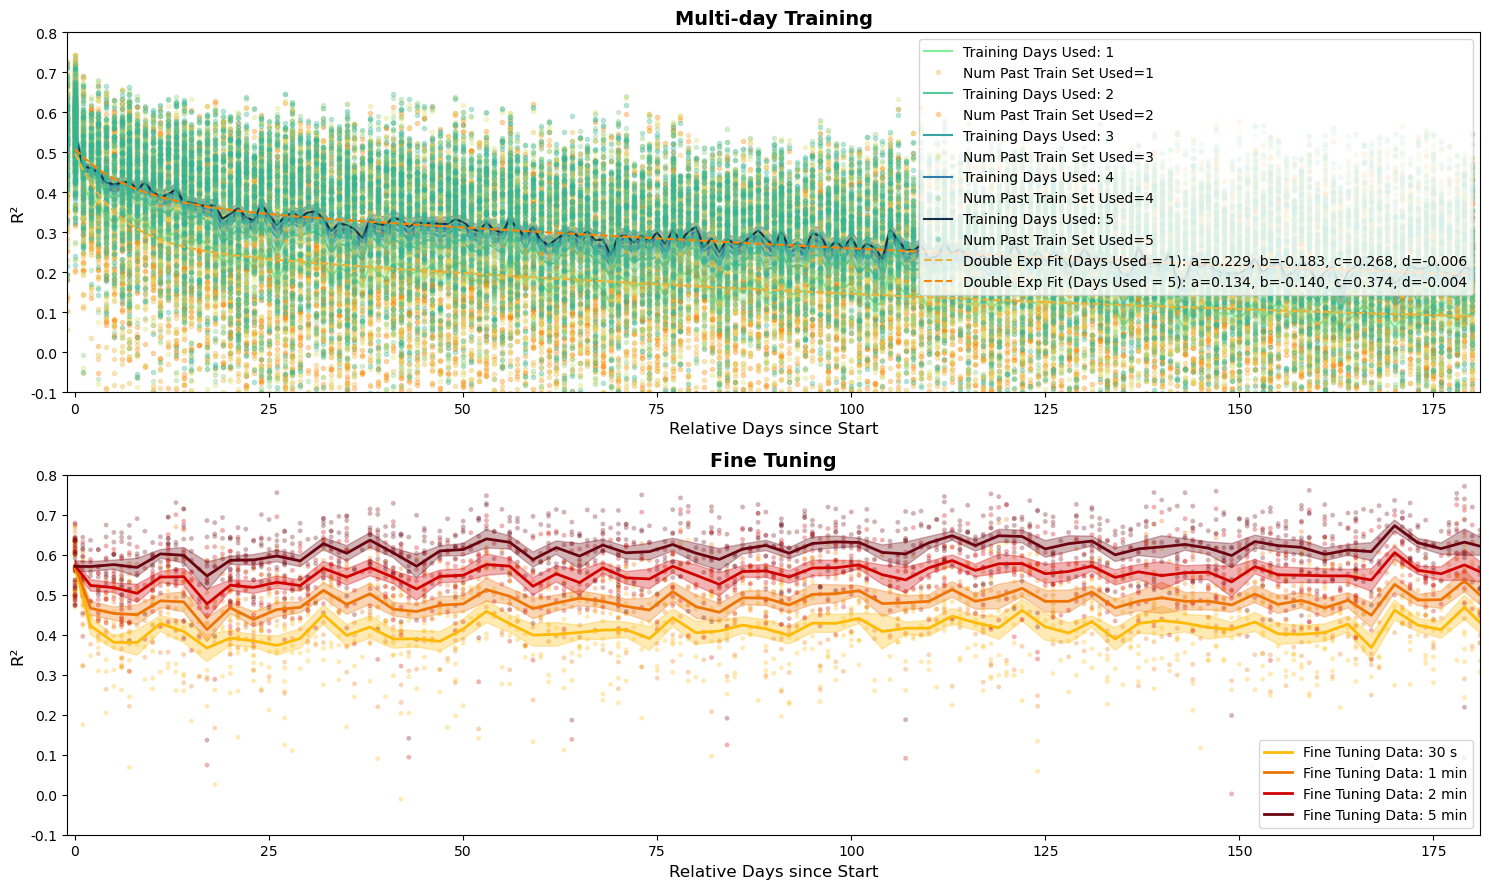

In [15]:
df = pd.read_csv('results_2025-07-24-10-39_day_20230612_170.csv')
fig,ax = plt.subplots(2,figsize=(15,9))
print(df['r2'].shape)
plot_multiday_training(ax[0], df)
results_file = "results_continual_learning_sweep_RDandCO_neuralnormupdated_20seeddays_200days.csv"
plot_continual_learning_sweep(ax[1], results_file)
fig.tight_layout()
plt.savefig('multiday_training_and_fine_tuning_with_fit.pdf')